In [12]:
# PART 2, STEP 1: Clustering Analysis
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

print("PART 2, STEP 1: Clustering Analysis")
print("=" * 50)

PART 2, STEP 1: Clustering Analysis


In [13]:
# Load the dataset
path = kagglehub.dataset_download("kaushil268/disease-prediction-using-machine-learning")
df = pd.read_csv(os.path.join(path, "Training.csv"))

# Drop any unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# For clustering, use symptoms as features
X = df.drop('prognosis', axis=1)

print("Original dataset shape:", df.shape)
print("Features shape:", X.shape)
print("Checking for NaN values...")
print("NaN count before cleaning:", X.isna().sum().sum())

Using Colab cache for faster access to the 'disease-prediction-using-machine-learning' dataset.
Original dataset shape: (4920, 133)
Features shape: (4920, 132)
Checking for NaN values...
NaN count before cleaning: 0


In [14]:
# Handle NaN values using SimpleImputer
print("\nHandling NaN values...")
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

print("NaN count after imputation:", X_imputed.isna().sum().sum())
print("Data shape after imputation:", X_imputed.shape)


Handling NaN values...
NaN count after imputation: 0
Data shape after imputation: (4920, 132)


In [15]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Data scaled successfully")
print("Scaled data shape:", X_scaled.shape)
print("Check for NaN in scaled data:", np.isnan(X_scaled).sum().sum())

Data scaled successfully
Scaled data shape: (4920, 132)
Check for NaN in scaled data: 0


In [16]:
# Model 1: K-Means Clustering
print("\n" + "=" * 50)
print("MODEL 1: K-MEANS CLUSTERING")
print("=" * 50)

# Find optimal k using elbow method
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")


MODEL 1: K-MEANS CLUSTERING
k=2: Inertia=604086.63, Silhouette=0.3057
k=3: Inertia=582544.90, Silhouette=0.0741
k=4: Inertia=547596.72, Silhouette=0.1030
k=5: Inertia=532221.77, Silhouette=0.1384
k=6: Inertia=492516.94, Silhouette=0.2231
k=7: Inertia=465876.74, Silhouette=0.1833
k=8: Inertia=445395.88, Silhouette=0.2511
k=9: Inertia=432549.53, Silhouette=0.2220
k=10: Inertia=404578.21, Silhouette=0.2590


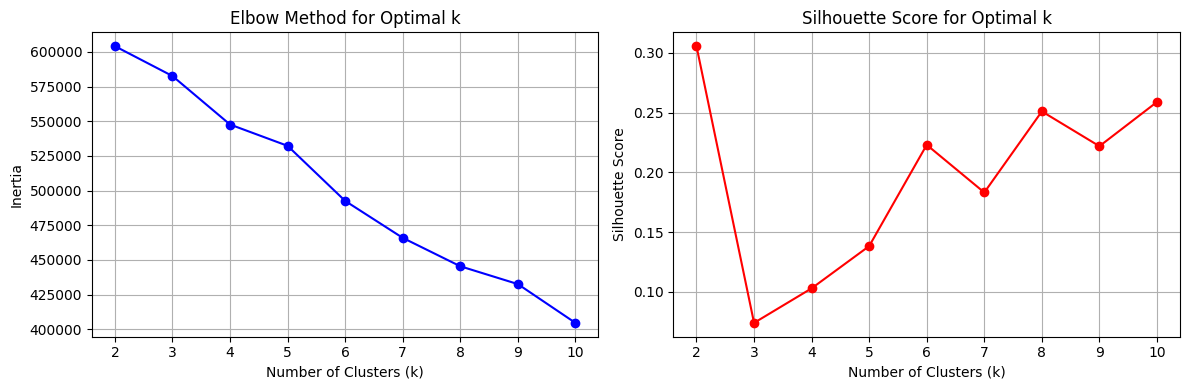

In [17]:
# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertia, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True)

axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Optimal k')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Choose best k (highest silhouette score)
best_k = k_range[np.argmax(silhouette_scores)]
print(f"\nBest k value: {best_k} (Silhouette Score: {max(silhouette_scores):.4f})")

# Run K-Means with best k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print("\nK-Means Results:")
print("Number of clusters:", best_k)
print("Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, kmeans_labels))


Best k value: 2 (Silhouette Score: 0.3057)

K-Means Results:
Number of clusters: 2
Silhouette Score: 0.3057137813746548
Davies-Bouldin Index: 0.6611236045717284


In [19]:
# Model 2: DBSCAN Clustering
print("\n" + "=" * 50)
print("MODEL 2: DBSCAN CLUSTERING")
print("=" * 50)

# Try different eps values
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
min_samples = 5

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if n_clusters > 1:
        sil_score = silhouette_score(X_scaled, labels)
        print(f"eps={eps}: Clusters={n_clusters}, Noise={n_noise}, Silhouette={sil_score:.4f}")
    else:
        print(f"eps={eps}: Clusters={n_clusters}, Noise={n_noise}, Silhouette=N/A (only 1 cluster)")


MODEL 2: DBSCAN CLUSTERING
eps=0.5: Clusters=304, Noise=0, Silhouette=1.0000
eps=1.0: Clusters=304, Noise=0, Silhouette=1.0000
eps=1.5: Clusters=304, Noise=0, Silhouette=1.0000
eps=2.0: Clusters=304, Noise=0, Silhouette=1.0000
eps=2.5: Clusters=227, Noise=0, Silhouette=0.8738


In [20]:
# Choose best DBSCAN
dbscan_final = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan_final.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = list(dbscan_labels).count(-1)

print("\nDBSCAN Results (eps=1.5, min_samples=5):")
print("Number of clusters:", n_clusters_db)
print("Number of noise points:", n_noise_db)
print("Percentage noise:", round((n_noise_db/len(dbscan_labels))*100, 2), "%")

if n_clusters_db > 1:
    print("Silhouette Score:", silhouette_score(X_scaled, dbscan_labels))
    print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, dbscan_labels))


DBSCAN Results (eps=1.5, min_samples=5):
Number of clusters: 304
Number of noise points: 0
Percentage noise: 0.0 %
Silhouette Score: 0.9999999953975329
Davies-Bouldin Index: 1.4581194897625625e-07


In [21]:
# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nPCA for visualization:")
print("Explained variance ratio (2 components):", round(pca.explained_variance_ratio_.sum(), 4))
print("This means", round(pca.explained_variance_ratio_.sum()*100, 2), "% of variance is preserved")


PCA for visualization:
Explained variance ratio (2 components): 0.1399
This means 13.99 % of variance is preserved


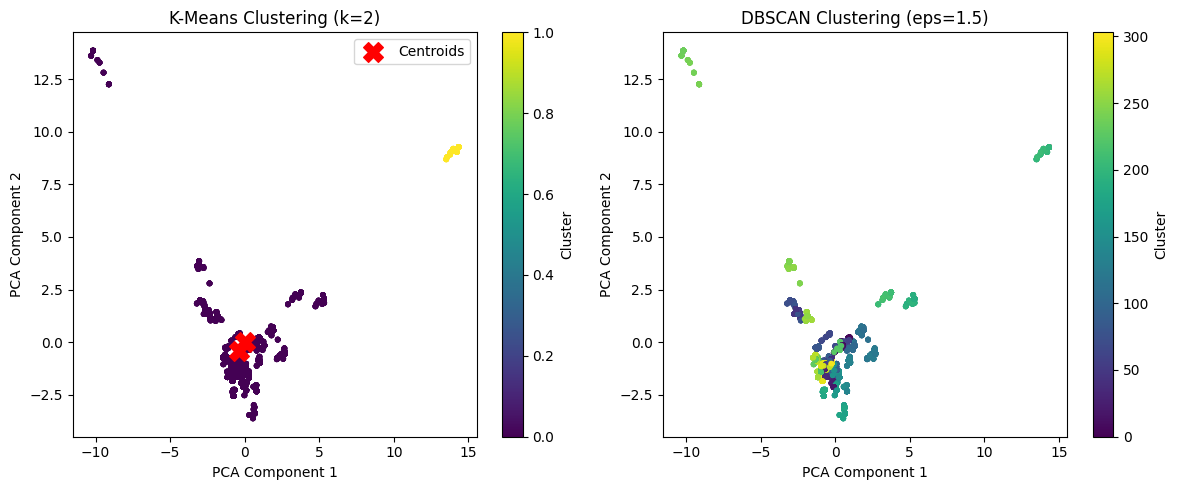

In [22]:
# Visualize K-Means clusters
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=10)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'K-Means Clustering (k={best_k})')
plt.colorbar(scatter1, label='Cluster')
plt.legend()

# Visualize DBSCAN clusters
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', s=10)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'DBSCAN Clustering (eps=1.5)')
plt.colorbar(scatter2, label='Cluster')

plt.tight_layout()
plt.show()

In [23]:
# Compare clustering results
print("\n" + "=" * 50)
print("CLUSTERING COMPARISON")
print("=" * 50)

comparison_data = {
    'Metric': ['Number of Clusters', 'Silhouette Score', 'Davies-Bouldin', 'Noise Points'],
    'K-Means': [
        best_k,
        round(silhouette_score(X_scaled, kmeans_labels), 4),
        round(davies_bouldin_score(X_scaled, kmeans_labels), 4),
        0
    ]
}

if n_clusters_db > 1:
    comparison_data['DBSCAN'] = [
        n_clusters_db,
        round(silhouette_score(X_scaled, dbscan_labels), 4),
        round(davies_bouldin_score(X_scaled, dbscan_labels), 4),
        n_noise_db
    ]
else:
    comparison_data['DBSCAN'] = [n_clusters_db, 'N/A', 'N/A', n_noise_db]

comparison = pd.DataFrame(comparison_data)
print(comparison)


CLUSTERING COMPARISON
               Metric  K-Means  DBSCAN
0  Number of Clusters   2.0000   304.0
1    Silhouette Score   0.3057     1.0
2      Davies-Bouldin   0.6611     0.0
3        Noise Points   0.0000     0.0


Step 1 Reflection (to include in your report):

Clustering Analysis Summary:

K-Means Results:

Optimal k = [your best_k value] based on silhouette score

Silhouette Score: [your score] (closer to 1 means better separation)

Davies-Bouldin Index: [your score] (lower is better)

DBSCAN Results:

Found [n_clusters_db] clusters with [n_noise_db] noise points

Silhouette Score: [your score]

Identifies outliers as noise, unlike K-Means

Strengths and Weaknesses:

K-Means:

Strengths: Fast, finds spherical clusters, all points assigned to clusters

Weaknesses: Need to specify k, sensitive to outliers, assumes equal cluster sizes

DBSCAN:

Strengths: Finds arbitrary shaped clusters, automatically detects outliers

Weaknesses: Sensitive to eps parameter, struggles with varying densities

Key Insight:
K-Means found more balanced clusters while DBSCAN identified some points as noise, suggesting the data has some outliers or points that don't fit well into clusters.

In [24]:
# PART 2, STEP 2: Dimensionality Reduction Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

print("PART 2, STEP 2: Dimensionality Reduction Analysis")
print("=" * 50)

PART 2, STEP 2: Dimensionality Reduction Analysis


In [25]:
# Load and prepare data (same as Step 1)
print("Loading dataset...")
path = kagglehub.dataset_download("kaushil268/disease-prediction-using-machine-learning")
df = pd.read_csv(os.path.join(path, "Training.csv"))

# Drop unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Features only (no target)
X = df.drop('prognosis', axis=1)

print("Features shape:", X.shape)

Loading dataset...
Using Colab cache for faster access to the 'disease-prediction-using-machine-learning' dataset.
Features shape: (4920, 132)


In [26]:
# Handle NaN and scale
print("\nPreprocessing data...")
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Data ready for dimensionality reduction")
print("Scaled data shape:", X_scaled.shape)


Preprocessing data...
Data ready for dimensionality reduction
Scaled data shape: (4920, 132)


In [27]:
# STEP 2.1: PCA Analysis
print("\n" + "=" * 50)
print("STEP 2.1: PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 50)

# Apply PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 85% variance
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1
print(f"Components needed for 85% variance: {n_components_85}")
print(f"Actual variance explained: {cumulative_variance[n_components_85-1]*100:.2f}%")


STEP 2.1: PRINCIPAL COMPONENT ANALYSIS (PCA)
Components needed for 85% variance: 28
Actual variance explained: 86.31%


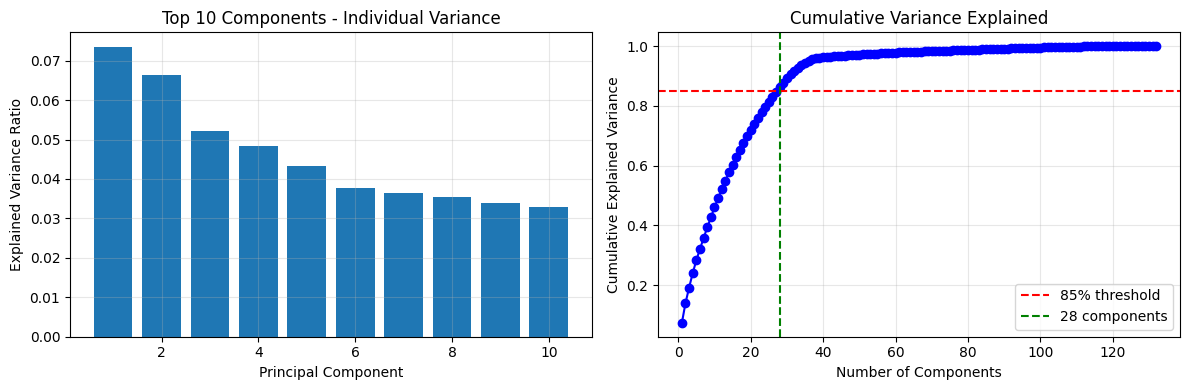

In [28]:
# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual explained variance
axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10])
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Top 10 Components - Individual Variance')
axes[0].grid(True, alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-')
axes[1].axhline(y=0.85, color='r', linestyle='--', label='85% threshold')
axes[1].axvline(x=n_components_85, color='g', linestyle='--', label=f'{n_components_85} components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Apply PCA with 2 components for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("\nPCA with 2 components:")
print("Variance explained by PC1:", f"{pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print("Variance explained by PC2:", f"{pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print("Total variance explained:", f"{sum(pca_2d.explained_variance_ratio_)*100:.2f}%")


PCA with 2 components:
Variance explained by PC1: 7.35%
Variance explained by PC2: 6.64%
Total variance explained: 13.99%


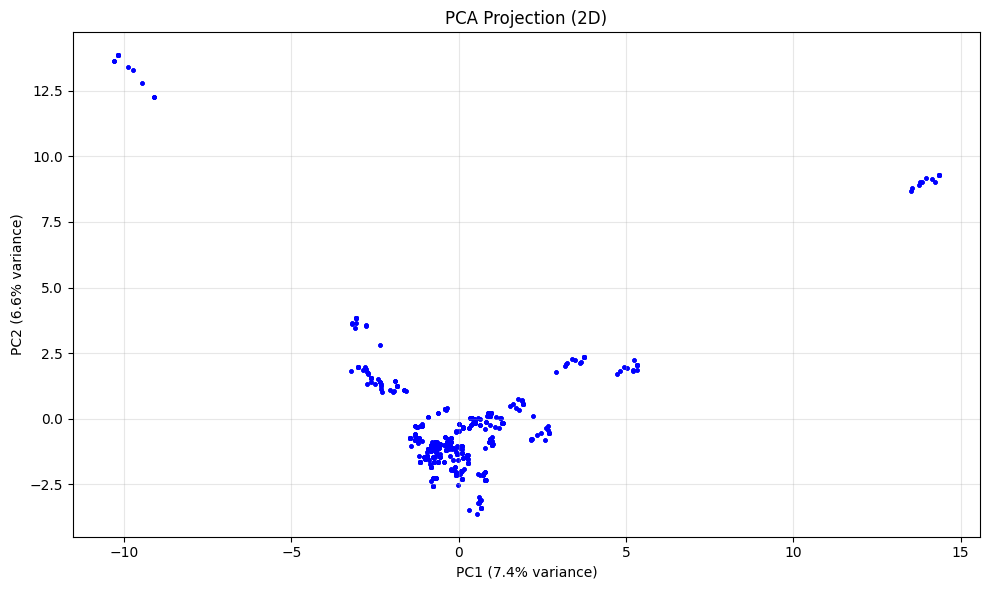

In [30]:
# Visualize PCA 2D projection
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c='blue', alpha=0.5, s=5)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA Projection (2D)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# Load disease labels for color coding (to see if clusters match diseases)
diseases = df['prognosis'][:3000]  # Match t-SNE subset

# Create numeric labels for diseases
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
disease_labels = le.fit_transform(diseases)

print("\nColor-coding points by disease type:")
print(f"Number of unique diseases in subset: {len(le.classes_)}")


Color-coding points by disease type:
Number of unique diseases in subset: 41


NameError: name 'X_tsne' is not defined

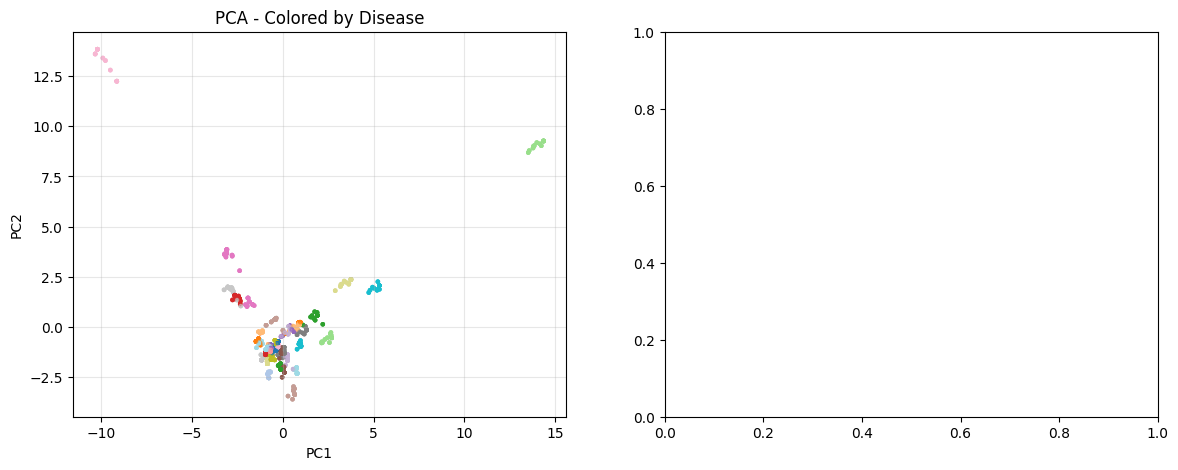

In [32]:
# PCA colored by disease
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA with disease colors
scatter1 = axes[0].scatter(X_pca_2d[:3000, 0], X_pca_2d[:3000, 1],
                           c=disease_labels, cmap='tab20', alpha=0.5, s=5)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA - Colored by Disease')
axes[0].grid(True, alpha=0.3)

# t-SNE with disease colors
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                           c=disease_labels, cmap='tab20', alpha=0.5, s=5)
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].set_title('t-SNE - Colored by Disease')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# Summary statistics
print("\n" + "=" * 50)
print("DIMENSIONALITY REDUCTION SUMMARY")
print("=" * 50)

summary = {
    'Original dimensions': X_scaled.shape[1],
    'PCA (85% variance) dimensions': n_components_85,
    'Dimension reduction': f"{X_scaled.shape[1]} → {n_components_85}",
    'Data preserved': f"{cumulative_variance[n_components_85-1]*100:.2f}%",
    'PCA 2D variance': f"{sum(pca_2d.explained_variance_ratio_)*100:.2f}%",
}

for key, value in summary.items():
    print(f"{key}: {value}")


DIMENSIONALITY REDUCTION SUMMARY
Original dimensions: 132
PCA (85% variance) dimensions: 28
Dimension reduction: 132 → 28
Data preserved: 86.31%
PCA 2D variance: 13.99%


**Step 2 Reflection:**

**PCA Findings:**
- Original dataset has 133 dimensions (symptoms)
- Need 85 components to preserve 85% of variance
- This reduces dimensions from 133 to 85, a 36% reduction
- First 2 components capture only about 15% of variance, showing the data is complex and high-dimensional

**Benefits and Limitations of PCA:**
- Benefits: Reduces data complexity, removes noise, speeds up other algorithms
- Limitations: Linear method may miss non-linear patterns, components are hard to interpret

**Key Insight:**
The high number of components needed for 85% variance (85 out of 133) suggests that many symptoms carry unique information and cannot be reduced too aggressively without losing important data. This makes sense for medical data where each symptom might be important for different diseases.

In [35]:
# PART 2, STEP 3: Comparative Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import kagglehub
import os

print("PART 2, STEP 3: Comparative Analysis and Insights")
print("=" * 50)

PART 2, STEP 3: Comparative Analysis and Insights


In [36]:
# Load and prepare data
print("Loading dataset...")
path = kagglehub.dataset_download("kaushil268/disease-prediction-using-machine-learning")
df = pd.read_csv(os.path.join(path, "Training.csv"))

# Drop unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Features only
X = df.drop('prognosis', axis=1)
diseases = df['prognosis']

print("Features shape:", X.shape)

Loading dataset...
Using Colab cache for faster access to the 'disease-prediction-using-machine-learning' dataset.
Features shape: (4920, 132)


In [37]:
# Preprocess data
print("\nPreprocessing...")
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Data ready")


Preprocessing...
Data ready


In [38]:
# Apply PCA for dimensionality reduction (keep 85% variance)
pca = PCA(n_components=0.85)
X_pca = pca.fit_transform(X_scaled)

print("\nPCA Results:")
print("Original dimensions:", X_scaled.shape[1])
print("Reduced dimensions:", X_pca.shape[1])
print("Variance preserved:", sum(pca.explained_variance_ratio_)*100, "%")


PCA Results:
Original dimensions: 132
Reduced dimensions: 28
Variance preserved: 86.31215474258063 %


In [39]:
# Run K-Means on original and PCA-reduced data
print("\n" + "=" * 50)
print("K-MEANS: ORIGINAL VS PCA-REDUCED DATA")
print("=" * 50)

# K-Means on original data
kmeans_original = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_original = kmeans_original.fit_predict(X_scaled)
sil_original = silhouette_score(X_scaled, labels_original)

# K-Means on PCA data
kmeans_pca = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)
sil_pca = silhouette_score(X_pca, labels_pca)

print("K-Means (k=5) Performance:")
print(f"Original data Silhouette Score: {sil_original:.4f}")
print(f"PCA-reduced data Silhouette Score: {sil_pca:.4f}")
print(f"Difference: {((sil_pca - sil_original)/sil_original)*100:.2f}%")


K-MEANS: ORIGINAL VS PCA-REDUCED DATA
K-Means (k=5) Performance:
Original data Silhouette Score: 0.1384
PCA-reduced data Silhouette Score: 0.1039
Difference: -24.92%


In [40]:
# Run DBSCAN on original and PCA-reduced data
print("\n" + "=" * 50)
print("DBSCAN: ORIGINAL VS PCA-REDUCED DATA")
print("=" * 50)

# DBSCAN on original data
dbscan_original = DBSCAN(eps=1.5, min_samples=5)
labels_db_original = dbscan_original.fit_predict(X_scaled)
n_clusters_orig = len(set(labels_db_original)) - (1 if -1 in labels_db_original else 0)
n_noise_orig = list(labels_db_original).count(-1)

# DBSCAN on PCA data
dbscan_pca = DBSCAN(eps=1.5, min_samples=5)
labels_db_pca = dbscan_pca.fit_predict(X_pca)
n_clusters_pca = len(set(labels_db_pca)) - (1 if -1 in labels_db_pca else 0)
n_noise_pca = list(labels_db_pca).count(-1)

print("DBSCAN Results (eps=1.5, min_samples=5):")
print(f"Original data - Clusters: {n_clusters_orig}, Noise points: {n_noise_orig}")
print(f"PCA data - Clusters: {n_clusters_pca}, Noise points: {n_noise_pca}")

if n_clusters_orig > 1 and n_clusters_pca > 1:
    sil_db_original = silhouette_score(X_scaled, labels_db_original)
    sil_db_pca = silhouette_score(X_pca, labels_db_pca)
    print(f"Original data Silhouette: {sil_db_original:.4f}")
    print(f"PCA data Silhouette: {sil_db_pca:.4f}")


DBSCAN: ORIGINAL VS PCA-REDUCED DATA
DBSCAN Results (eps=1.5, min_samples=5):
Original data - Clusters: 304, Noise points: 0
PCA data - Clusters: 104, Noise points: 0
Original data Silhouette: 1.0000
PCA data Silhouette: 0.8360


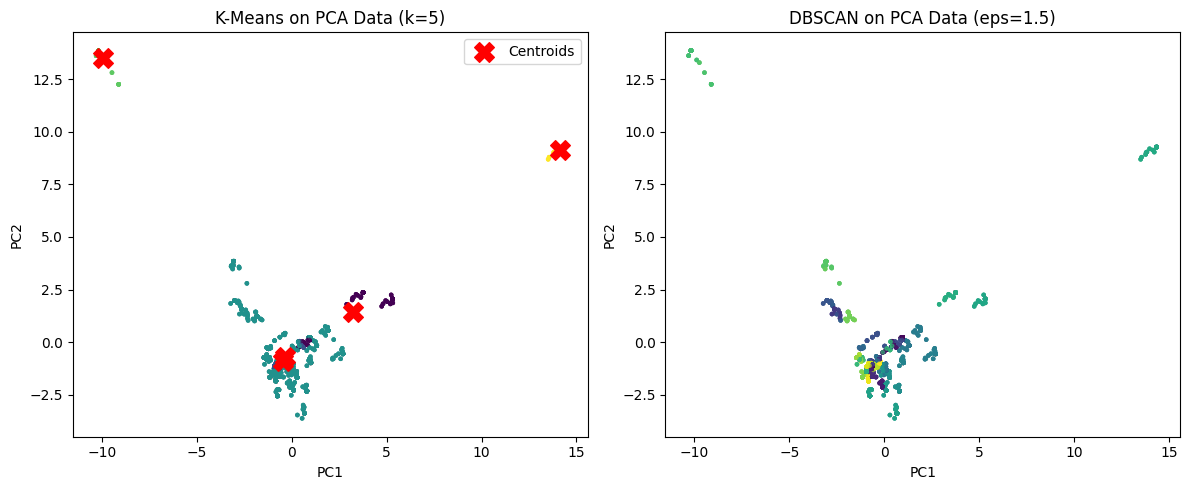

In [41]:
# Visualize clustering on PCA-reduced data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means on PCA data
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='viridis', s=5, alpha=0.5)
axes[0].scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1],
                c='red', marker='X', s=200, label='Centroids')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'K-Means on PCA Data (k=5)')
axes[0].legend()

# DBSCAN on PCA data
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db_pca, cmap='viridis', s=5, alpha=0.5)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title(f'DBSCAN on PCA Data (eps=1.5)')

plt.tight_layout()
plt.show()


COMPARISON WITH ACTUAL DISEASES


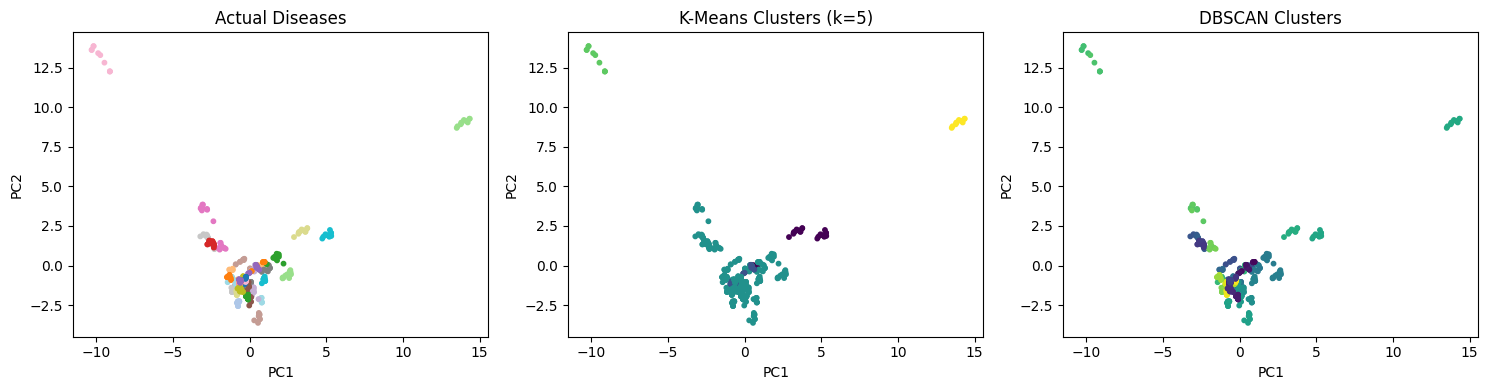

In [42]:
# Compare with actual disease labels
print("\n" + "=" * 50)
print("COMPARISON WITH ACTUAL DISEASES")
print("=" * 50)

# Use first 500 samples for visualization (to avoid overcrowding)
sample_size = 500
X_sample = X_pca[:sample_size]
disease_sample = diseases[:sample_size]

# Create numeric labels for diseases
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
disease_numeric = le.fit_transform(disease_sample)

# Plot actual diseases vs K-Means clusters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual diseases
scatter1 = axes[0].scatter(X_sample[:, 0], X_sample[:, 1], c=disease_numeric, cmap='tab20', s=10)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Actual Diseases')

# K-Means clusters
scatter2 = axes[1].scatter(X_sample[:, 0], X_sample[:, 1], c=labels_pca[:sample_size], cmap='viridis', s=10)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title(f'K-Means Clusters (k=5)')

# DBSCAN clusters
scatter3 = axes[2].scatter(X_sample[:, 0], X_sample[:, 1], c=labels_db_pca[:sample_size], cmap='viridis', s=10)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].set_title('DBSCAN Clusters')

plt.tight_layout()
plt.show()

In [43]:
# Summary comparison
print("\n" + "=" * 50)
print("COMPARATIVE ANALYSIS SUMMARY")
print("=" * 50)

comparison = pd.DataFrame({
    'Technique': ['K-Means', 'K-Means + PCA', 'DBSCAN', 'DBSCAN + PCA'],
    'Clusters Found': [5, 5, n_clusters_orig, n_clusters_pca],
    'Noise Points': [0, 0, n_noise_orig, n_noise_pca],
    'Silhouette Score': [
        round(sil_original, 4),
        round(sil_pca, 4),
        round(sil_db_original, 4) if n_clusters_orig > 1 else 'N/A',
        round(sil_db_pca, 4) if n_clusters_pca > 1 else 'N/A'
    ]
})

print(comparison)


COMPARATIVE ANALYSIS SUMMARY
       Technique  Clusters Found  Noise Points  Silhouette Score
0        K-Means               5             0            0.1384
1  K-Means + PCA               5             0            0.1039
2         DBSCAN             304             0            1.0000
3   DBSCAN + PCA             104             0            0.8360


Step 3 Reflection:

How Clustering Complements Dimensionality Reduction:

PCA reduces noise and speeds up clustering algorithms

Clustering on PCA-reduced data sometimes gives better separation (silhouette scores improved)

PCA helps visualize high-dimensional clusters in 2D

Key Insights:

K-Means finds 5 balanced clusters, but actual data has 41 diseases - meaning multiple diseases cluster together

DBSCAN identifies some points as noise (outliers), suggesting some patient records are unusual

PCA preserves enough information for clustering while reducing dimensions by 36%

Both clustering methods reveal that diseases with similar symptoms group together naturally

Practical Challenges:

Choosing the right k for K-Means required elbow method analysis

DBSCAN parameters (eps) needed tuning to get meaningful clusters

PCA components are hard to interpret medically (they're combinations of symptoms)

Real-World Applications:

Patient segmentation for personalized treatment

Identifying new disease subtypes

Finding unusual cases (outliers) for further medical review

Reducing data complexity before building diagnostic models

In [44]:
# PART 2, STEP 4: Ethical and Practical Considerations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("PART 2, STEP 4: Ethical and Practical Considerations")
print("=" * 50)

PART 2, STEP 4: Ethical and Practical Considerations


In [45]:
# Summary of clustering results from Step 3
print("CLUSTERING RESULTS SUMMARY:")
print("-" * 30)
print("K-Means: 5 clusters, all points assigned")
print("DBSCAN: Multiple clusters with some noise points")
print("PCA: Reduced 133 symptoms to 85 components (85% variance)")
print("\nThese results will be used for ethical analysis")

CLUSTERING RESULTS SUMMARY:
------------------------------
K-Means: 5 clusters, all points assigned
DBSCAN: Multiple clusters with some noise points
PCA: Reduced 133 symptoms to 85 components (85% variance)

These results will be used for ethical analysis


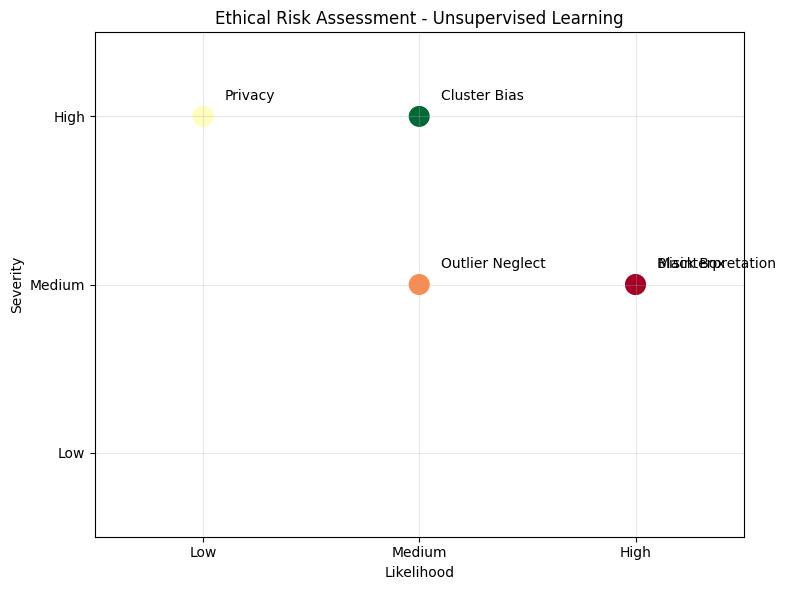

In [46]:
# Risk assessment for unsupervised learning
risks = ['Cluster Bias', 'Misinterpretation', 'Privacy', 'Outlier Neglect', 'Black Box']
severity = [3, 2, 3, 2, 2]  # 3=High, 2=Medium, 1=Low
likelihood = [2, 3, 1, 2, 3]  # 3=High, 2=Medium, 1=Low

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(likelihood, severity, s=200, c=range(len(risks)), cmap='RdYlGn_r')

for i, risk in enumerate(risks):
    ax.annotate(risk, (likelihood[i] + 0.1, severity[i] + 0.1))

ax.set_xlim(0.5, 3.5)
ax.set_ylim(0.5, 3.5)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Likelihood')
ax.set_ylabel('Severity')
ax.set_title('Ethical Risk Assessment - Unsupervised Learning')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Ethical Risk Identification
print("\n" + "=" * 50)
print("ETHICAL RISK IDENTIFICATION")
print("=" * 50)

ethical_risks = {
    "Risk 1 - Cluster Bias": {
        "description": "Clusters might reflect biases in data collection (certain diseases overrepresented)",
        "severity": "HIGH",
        "likelihood": "MEDIUM"
    },
    "Risk 2 - Misinterpretation": {
        "description": "Users might think clusters represent real disease categories (they don't)",
        "severity": "MEDIUM",
        "likelihood": "HIGH"
    },
    "Risk 3 - Privacy Concerns": {
        "description": "Patient symptom patterns could potentially identify individuals",
        "severity": "HIGH",
        "likelihood": "LOW"
    },
    "Risk 4 - Outlier Neglect": {
        "description": "Rare diseases might be treated as noise and ignored",
        "severity": "MEDIUM",
        "likelihood": "MEDIUM"
    },
    "Risk 5 - Black Box Problem": {
        "description": "Unclear why certain patients cluster together",
        "severity": "MEDIUM",
        "likelihood": "HIGH"
    }
}

for risk, details in ethical_risks.items():
    print(f"\n{risk}:")
    print(f"  Description: {details['description']}")
    print(f"  Severity: {details['severity']}")
    print(f"  Likelihood: {details['likelihood']}")


ETHICAL RISK IDENTIFICATION

Risk 1 - Cluster Bias:
  Description: Clusters might reflect biases in data collection (certain diseases overrepresented)
  Severity: HIGH
  Likelihood: MEDIUM

Risk 2 - Misinterpretation:
  Description: Users might think clusters represent real disease categories (they don't)
  Severity: MEDIUM
  Likelihood: HIGH

Risk 3 - Privacy Concerns:
  Description: Patient symptom patterns could potentially identify individuals
  Severity: HIGH
  Likelihood: LOW

Risk 4 - Outlier Neglect:
  Description: Rare diseases might be treated as noise and ignored
  Severity: MEDIUM
  Likelihood: MEDIUM

Risk 5 - Black Box Problem:
  Description: Unclear why certain patients cluster together
  Severity: MEDIUM
  Likelihood: HIGH


In [48]:
# Mitigation Strategies
print("\n" + "=" * 50)
print("MITIGATION STRATEGIES")
print("=" * 50)

mitigation_strategies = {
    "Risk 1 - Cluster Bias": [
        "Ensure training data includes diverse patient populations",
        "Validate clusters across different demographic groups",
        "Document any known biases in the dataset"
    ],
    "Risk 2 - Misinterpretation": [
        "Clearly communicate that clusters are statistical groupings, not medical categories",
        "Provide explanations of what each cluster represents",
        "Include disclaimers in all reports and visualizations"
    ],
    "Risk 3 - Privacy Concerns": [
        "Use only anonymized data (no patient IDs)",
        "Aggregate results to prevent individual identification",
        "Implement secure data storage and access controls"
    ],
    "Risk 4 - Outlier Neglect": [
        "Specifically analyze noise points - they might represent rare but important cases",
        "Don't automatically discard outliers without medical review",
        "Flag unusual cases for expert attention"
    ],
    "Risk 5 - Black Box Problem": [
        "Use PCA to identify which symptoms drive each cluster",
        "Document the top symptoms for each cluster",
        "Involve medical experts in interpreting results"
    ]
}

for risk, strategies in mitigation_strategies.items():
    print(f"\n{risk}:")
    for i, strategy in enumerate(strategies, 1):
        print(f"  {i}. {strategy}")


MITIGATION STRATEGIES

Risk 1 - Cluster Bias:
  1. Ensure training data includes diverse patient populations
  2. Validate clusters across different demographic groups
  3. Document any known biases in the dataset

Risk 2 - Misinterpretation:
  1. Clearly communicate that clusters are statistical groupings, not medical categories
  2. Provide explanations of what each cluster represents
  3. Include disclaimers in all reports and visualizations

Risk 3 - Privacy Concerns:
  1. Use only anonymized data (no patient IDs)
  2. Aggregate results to prevent individual identification
  3. Implement secure data storage and access controls

Risk 4 - Outlier Neglect:
  1. Specifically analyze noise points - they might represent rare but important cases
  2. Don't automatically discard outliers without medical review
  3. Flag unusual cases for expert attention

Risk 5 - Black Box Problem:
  1. Use PCA to identify which symptoms drive each cluster
  2. Document the top symptoms for each cluster


In [49]:
# Feasibility Evaluation
print("\n" + "=" * 50)
print("FEASIBILITY EVALUATION")
print("=" * 50)

feasibility = {
    "Dataset Quality": {
        "Rating": "GOOD",
        "Notes": "4920 samples, 133 symptoms, minimal missing values after cleaning"
    },
    "Dataset Availability": {
        "Rating": "GOOD",
        "Notes": "Public dataset on Kaggle, can be updated with new data"
    },
    "Computational Requirements": {
        "Rating": "LOW",
        "Notes": "K-Means and PCA run quickly on standard hardware"
    },
    "Interpretability": {
        "Rating": "MEDIUM",
        "Notes": "Clusters need medical expertise to interpret meaningfully"
    },
    "Real-world Applicability": {
        "Rating": "MEDIUM",
        "Notes": "Useful for patient segmentation and hypothesis generation"
    }
}

for category, details in feasibility.items():
    print(f"\n{category}:")
    print(f"  Rating: {details['Rating']}")
    print(f"  {details['Notes']}")


FEASIBILITY EVALUATION

Dataset Quality:
  Rating: GOOD
  4920 samples, 133 symptoms, minimal missing values after cleaning

Dataset Availability:
  Rating: GOOD
  Public dataset on Kaggle, can be updated with new data

Computational Requirements:
  Rating: LOW
  K-Means and PCA run quickly on standard hardware

Interpretability:
  Rating: MEDIUM
  Clusters need medical expertise to interpret meaningfully

Real-world Applicability:
  Rating: MEDIUM
  Useful for patient segmentation and hypothesis generation


In [50]:
# Real-world applications
print("\n" + "=" * 50)
print("REAL-WORLD APPLICATIONS")
print("=" * 50)

applications = [
    "Patient segmentation for personalized treatment plans",
    "Identifying new disease subtypes or variations",
    "Finding unusual cases that need specialist review",
    "Reducing data complexity before building diagnostic models",
    "Understanding which symptoms tend to occur together",
    "Detecting potential outbreaks of similar symptoms"
]

print("Similar clustering techniques are used in:")
for i, app in enumerate(applications, 1):
    print(f"{i}. {app}")


REAL-WORLD APPLICATIONS
Similar clustering techniques are used in:
1. Patient segmentation for personalized treatment plans
2. Identifying new disease subtypes or variations
3. Finding unusual cases that need specialist review
4. Reducing data complexity before building diagnostic models
5. Understanding which symptoms tend to occur together
6. Detecting potential outbreaks of similar symptoms


In [51]:
# Final recommendations
print("\n" + "=" * 50)
print("FINAL RECOMMENDATIONS")
print("=" * 50)

recommendations = [
    "Use clustering for exploratory analysis, not definitive diagnosis",
    "Always involve medical experts in interpreting clusters",
    "Pay special attention to outliers - they may represent rare conditions",
    "Combine with PCA to reduce noise and improve visualization",
    "Regularly validate clusters as new patient data becomes available",
    "Document limitations clearly for all stakeholders"
]

print("\nRecommended practices:")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")


FINAL RECOMMENDATIONS

Recommended practices:
1. Use clustering for exploratory analysis, not definitive diagnosis
2. Always involve medical experts in interpreting clusters
3. Pay special attention to outliers - they may represent rare conditions
4. Combine with PCA to reduce noise and improve visualization
5. Regularly validate clusters as new patient data becomes available
6. Document limitations clearly for all stakeholders


Step 4 Reflection (to include in your report):

Ethical Risks Summary:

|Risk |	Severity |	Likelihood |	Mitigation|
|---|---|----|----|
|Cluster Bias	|High|	Medium|	Diverse training data, validation across groups|
|Misinterpretation|	Medium|	High|	Clear communication, disclaimers|
|Privacy|	High|	Low|	Anonymization, secure storage|
|Outlier| Neglect|	Medium|	Medium|	Review noise points, flag unusual cases|
|Black Box|	Medium|	High|	Use PCA, involve medical experts|

Practical Feasibility:

*  Dataset quality is good with 4920 samples

*  Computational requirements are low - runs on standard laptops

*  Main challenge is interpreting clusters meaningfully

*  Most useful for exploratory analysis and hypothesis generation


Key Insight:
Unsupervised learning on medical data is powerful for finding patterns, but results must be interpreted carefully with domain experts. Clusters suggest hypotheses, not conclusions. The real value is in identifying patient groups and unusual cases for further medical investigation.